In [1]:
using LinearAlgebra
using Plots

gr()

Plots.GRBackend()

In [2]:
function numerical_hessian_2d(g, λ; h=1e-5)
    λ0, λ1 = λ

    g00 = g([λ0, λ1])

    g_pp_00 = g([λ0 + h, λ1])
    g_mm_00 = g([λ0 - h, λ1])
    h11 = (g_pp_00 - 2.0 * g00 + g_mm_00) / (h^2)

    g_pp_11 = g([λ0, λ1 + h])
    g_mm_11 = g([λ0, λ1 - h])
    h22 = (g_pp_11 - 2.0 * g00 + g_mm_11) / (h^2)

    g_pp = g([λ0 + h, λ1 + h])
    g_pm = g([λ0 + h, λ1 - h])
    g_mp = g([λ0 - h, λ1 + h])
    g_mm = g([λ0 - h, λ1 - h])
    h12 = (g_pp - g_pm - g_mp + g_mm) / (4.0 * h^2)

    return [h11 h12; h12 h22]
end

function lambda_gradient(grad_f, x, grad_x, Δx_prev, λ)
    λ0, λ1 = λ
    y = x - λ0 * grad_x + λ1 * Δx_prev
    gy = grad_f(y)

    dg_dλ0 = -dot(gy, grad_x)
    dg_dλ1 = dot(gy, Δx_prev)

    return [dg_dλ0, dg_dλ1]
end

function solve_lambdas_newton(f, grad_f, x, grad_x, Δx_prev;
                              λ_init=[1.0, 1.0],
                              tol=1e-8,
                              max_iter=30)
    g(λ) = f(x - λ[1] * grad_x + λ[2] * Δx_prev)

    λ = copy(λ_init)

    for _ in 1:max_iter
        grad_λ = lambda_gradient(grad_f, x, grad_x, Δx_prev, λ)
        if norm(grad_λ) < tol
            break
        end

        H = numerical_hessian_2d(g, λ)

        H_reg = H + 1e-10I
        p = -(H_reg \ grad_λ)

        t = 1.0
        g_curr = g(λ)
        armijo_c = 1e-4

        while t > 1e-8
            λ_try = λ + t * p
            if g(λ_try) <= g_curr + armijo_c * t * dot(grad_λ, p)
                λ = λ_try
                break
            end
            t *= 0.5
        end

        if t <= 1e-8
            λ -= 1e-2 * grad_λ
        end
    end

    return λ
end

function compose_candidate(x, grad_x, deltas, λ)
    y = x - λ[1] * grad_x
    for j in 2:length(λ)
        y += λ[j] * deltas[j - 1]
    end
    return y
end


compose_candidate (generic function with 1 method)

In [3]:
function multicriteria_search(f, grad_f, x0;
                              tol=1e-6,
                              max_iter=400,
                              reset_each_n_plus_one=true,
                              verbose=true,
                              lambda_count=2)
    n = length(x0)

    x_prev = copy(x0)
    x = copy(x0)

    # Храним несколько предыдущих шагов только для lambda_count > 2
    deltas_history = Vector{Vector{Float64}}()

    history = [(
        iter=0,
        x=copy(x),
        fx=f(x),
        grad_norm=norm(grad_f(x)),
        λ0=0.0,
        λ1=0.0,
        Δx_norm=0.0
    )]

    converged = false

    for k in 1:max_iter
        grad_x = grad_f(x)
        grad_norm = norm(grad_x)

        if grad_norm < tol
            converged = true
            if verbose
                println("Сходимость достигнута на итерации $(k - 1): ||∇f|| = $(grad_norm)")
            end
            break
        end

        if lambda_count == 2
            # Ветка для старой 2-λ версии: передаём ОДИН вектор Δx_prev
            Δx_prev = x - x_prev
            if reset_each_n_plus_one && ((k - 1) % (n + 1) == 0)
                Δx_prev .= 0.0
            end

            λ = solve_lambdas_newton(f, grad_f, x, grad_x, Δx_prev; λ_init=[1.0, 1.0])
            λ0, λ1 = λ
            x_next = x - λ0 * grad_x + λ1 * Δx_prev

            x_prev = x
            x = x_next

            push!(history, (
                iter=k,
                x=copy(x),
                fx=f(x),
                grad_norm=norm(grad_f(x)),
                λ0=λ0,
                λ1=λ1,
                Δx_norm=norm(Δx_prev)
            ))
        else
            # Ветка для multi-λ версии: передаём коллекцию векторов deltas
            if k > 1
                Δx_prev = x - history[end].x
                push!(deltas_history, copy(Δx_prev))

                while length(deltas_history) > lambda_count - 1
                    popfirst!(deltas_history)
                end

                if reset_each_n_plus_one && ((k - 1) % (n + 1) == 0)
                    empty!(deltas_history)
                end
            end

            deltas_for_solve = isempty(deltas_history) ? Vector{Vector{Float64}}() : deltas_history
            λ = solve_lambdas_newton(f, grad_f, x, grad_x, deltas_for_solve; λ_init=nothing)
            x_next = compose_candidate(x, grad_x, deltas_for_solve, λ)
            λ0 = λ[1]
            λ1 = length(λ) > 1 ? λ[2] : 0.0

            x = x_next

            push!(history, (
                iter=k,
                x=copy(x),
                fx=f(x),
                grad_norm=norm(grad_f(x)),
                λ0=λ0,
                λ1=λ1,
                Δx_norm=isempty(deltas_for_solve) ? 0.0 : norm(deltas_for_solve[end])
            ))
        end
    end

    if !converged && verbose
        println("Достигнут лимит итераций $(max_iter), финальная ||∇f|| = $(history[end].grad_norm)")
    end

    return x, history
end


multicriteria_search (generic function with 1 method)


===== Rosenbrock =====
x*         = [1.0000000000000169, 1.0000000000000333]
f(x*)      = 3.0450030941531056e-28
||∇f(x*)|| = 2.2928769301371233e-13
iterations = 2

===== Rastrigin =====
x*         = [0.0, 0.0]
f(x*)      = 0.0
||∇f(x*)|| = 0.0
iterations = 3

===== Schwefel =====
x*         = [203.8142526488914, 203.81425264889282]
f(x*)      = 434.2793642362783
||∇f(x*)|| = 8.920542172045004e-13
iterations = 15

===== Quadratic a=1.0, b=1.0 =====
x*         = [0.0, 0.0]
f(x*)      = 0.0
||∇f(x*)|| = 0.0
iterations = 1

===== Quadratic a=1.0, b=5.0 =====
x*         = [5.551115123125783e-17, 1.1102230246251565e-16]
f(x*)      = 6.471124613141112e-32
||∇f(x*)|| = 1.1157603309187458e-15
iterations = 2

===== Quadratic a=1.0, b=10.0 =====
x*         = [-3.7470027081099033e-16, -5.551115123125783e-17]
f(x*)      = 1.7121517205602527e-31
||∇f(x*)|| = 1.3394761424494089e-15
iterations = 2


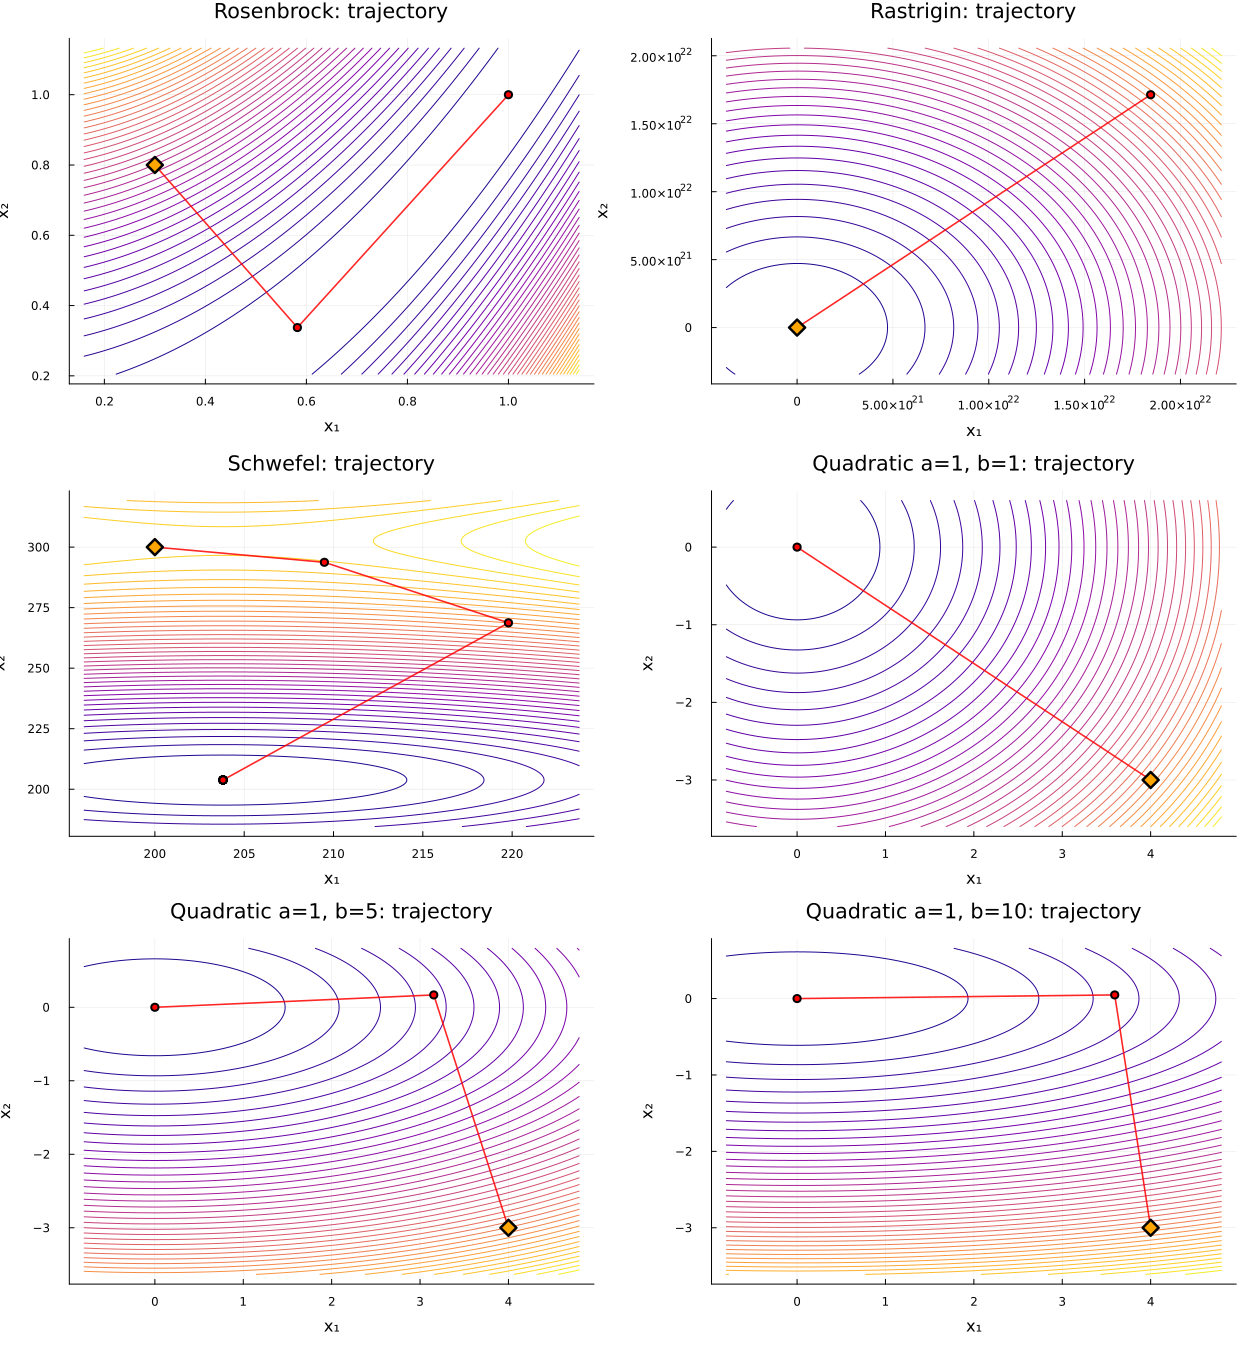

In [4]:
f_rosen(x) = (1.0 - x[1])^2 + 100.0 * (x[2] - x[1]^2)^2

function grad_rosen(x)
    return [
        -2.0 * (1.0 - x[1]) - 400.0 * x[1] * (x[2] - x[1]^2),
        200.0 * (x[2] - x[1]^2)
    ]
end

function f_rastrigin(x; A=10.0)
    n = length(x)
    return A * n + sum(xi^2 - A * cos(2.0 * pi * xi) for xi in x)
end

function grad_rastrigin(x; A=10.0)
    return [2.0 * xi + 2.0 * pi * A * sin(2.0 * pi * xi) for xi in x]
end

function f_schwefel(x)
    n = length(x)
    result = 0.0
    for xi in x
        if !isfinite(xi)
            return Inf  # Если вход Inf/NaN, возвращаем Inf
        end
        abs_xi = abs(xi)
        if abs_xi > 1e10  # Ограничиваем очень большие значения
            result += abs_xi * 1.0  # Приближение для очень больших xi
        else
            s = sqrt(abs_xi)
            if isfinite(s)
                result += xi * sin(s)
            else
                result += abs_xi * 1.0
            end
        end
    end
    return 418.9829 * n - result
end

function grad_schwefel(x)
    g = zeros(length(x))
    for i in eachindex(x)
        xi = x[i]
        if !isfinite(xi)
            g[i] = 0.0
            continue
        end
        
        abs_xi = abs(xi)
        if abs_xi > 1e10
            g[i] = -1.0  # Приближение для очень больших xi
        else
            s = sqrt(abs_xi)
            if s < 1e-12
                g[i] = 0.0
            elseif isfinite(s)
                g[i] = -(sin(s) + 0.5 * s * cos(s))
            else
                g[i] = -1.0
            end
        end
    end
    return g
end

f_quad(x, a, b) = a * x[1]^2 + b * x[2]^2
grad_quad(x, a, b) = [2.0 * a * x[1], 2.0 * b * x[2]]

function print_result(name, x, f, grad_f, hist)
    println("\n===== " * name * " =====")
    println("x*         = ", x)
    println("f(x*)      = ", f(x))
    println("||∇f(x*)|| = ", norm(grad_f(x)))
    println("iterations = ", length(hist) - 1)
end

function plot_run_2d(f, hist; xlim=(-5.0, 5.0), ylim=(-5.0, 5.0), title_prefix="", auto_zoom=true, zoom_pad=0.2, min_span=0.5)
    xs = [h.x[1] for h in hist]
    ys = [h.x[2] for h in hist]

    if auto_zoom && length(xs) > 0
        xmin, xmax = minimum(xs), maximum(xs)
        ymin, ymax = minimum(ys), maximum(ys)
        xspan = max(xmax - xmin, min_span)
        yspan = max(ymax - ymin, min_span)
        xpad = zoom_pad * xspan
        ypad = zoom_pad * yspan
        xlim = (xmin - xpad, xmax + xpad)
        ylim = (ymin - ypad, ymax + ypad)
    end

    xg = range(xlim[1], xlim[2], length=260)
    yg = range(ylim[1], ylim[2], length=260)
    Z = [f([x, y]) for y in yg, x in xg]

    p = contour(
        xg,
        yg,
        Z,
        levels=40,
        linewidth=1,
        c=:plasma,
        xlabel="x₁",
        ylabel="x₂",
        title=title_prefix * ": trajectory",
        legend=false
    )

    plot!(p, xs, ys, lw=1.6, linealpha=0.85, color=:red, label="trajectory")

    scatter!(
        p,
        xs,
        ys,
        marker=:circle,
        ms=4,
        color=:red,
        markerstrokewidth=0.8,
        markerstrokecolor=:black,
        alpha=1.0,
        label="all points"
    )

    scatter!(p, [xs[1]], [ys[1]], marker=:diamond, ms=8, color=:orange, markerstrokecolor=:black, markerstrokewidth=1.0, label="start")

    return p
end

rosen_tol, rosen_max_iter = 1e-12, 800
ras_tol, ras_max_iter = 1e-12, 800
sch_tol, sch_max_iter = 1e-12, 800

x0_rosen = [0.3, 0.8]
x_rosen, hist_rosen = multicriteria_search(f_rosen, grad_rosen, x0_rosen; tol=rosen_tol, max_iter=rosen_max_iter, verbose=false)
print_result("Rosenbrock", x_rosen, f_rosen, grad_rosen, hist_rosen)

x0_ras = [1.7, 3.7]
x_ras, hist_ras = multicriteria_search(f_rastrigin, grad_rastrigin, x0_ras; tol=ras_tol, max_iter=ras_max_iter, verbose=false)
print_result("Rastrigin", x_ras, f_rastrigin, grad_rastrigin, hist_ras)

x0_sch = [200.0, 300.0]
x_sch, hist_sch = multicriteria_search(f_schwefel, grad_schwefel, x0_sch; tol=sch_tol, max_iter=sch_max_iter, verbose=false)
print_result("Schwefel", x_sch, f_schwefel, grad_schwefel, hist_sch)

a_quad = 1.0
quad_cases = [1.0, 5.0, 10.0]
quad_runs = Vector{NamedTuple}(undef, length(quad_cases))

for (i, b_quad) in enumerate(quad_cases)
    fq(x) = f_quad(x, a_quad, b_quad)
    gq(x) = grad_quad(x, a_quad, b_quad)

    x0_quad = [4.0, -3.0]
    x_quad, hist_quad = multicriteria_search(fq, gq, x0_quad; tol=1e-12, max_iter=400, verbose=false)
    print_result("Quadratic a=$(a_quad), b=$(b_quad)", x_quad, fq, gq, hist_quad)

    quad_runs[i] = (b=b_quad, hist=hist_quad)
end

p_ros = plot_run_2d(f_rosen, hist_rosen; title_prefix="Rosenbrock", auto_zoom=true, min_span=0.5)
p_ras = plot_run_2d(f_rastrigin, hist_ras; title_prefix="Rastrigin", auto_zoom=true, min_span=0.5)
p_sch = plot_run_2d(f_schwefel, hist_sch; title_prefix="Schwefel", auto_zoom=true, min_span=10.0)

p_q1 = plot_run_2d(x -> f_quad(x, a_quad, 1.0), quad_runs[1].hist; title_prefix="Quadratic a=1, b=1", auto_zoom=true, min_span=0.5)
p_q5 = plot_run_2d(x -> f_quad(x, a_quad, 5.0), quad_runs[2].hist; title_prefix="Quadratic a=1, b=5", auto_zoom=true, min_span=0.5)
p_q10 = plot_run_2d(x -> f_quad(x, a_quad, 10.0), quad_runs[3].hist; title_prefix="Quadratic a=1, b=10", auto_zoom=true, min_span=0.5)

plot(p_ros, p_ras, p_sch, p_q1, p_q5, p_q10, layout=(3, 2), size=(1250, 1350))
